## make koppen-geiger climate images

In [1]:
# setup imports
import sys
from pathlib import Path

from tqdm.notebook import tqdm

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.paths import *
from src.paths import KOPPEN_FIGURES, KOPPEN_GEIGER
from src.plotting import analyse_koppen_geiger, plot_climate_class_timeseries
from src.utils import KOPPEN_DESCRIPTION, load_koppen_pickles_from_folder

In [2]:
# folder with shapefiles
test_path = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools/shapefiles_converter"
)


# Define shapefiles (adjust paths if needed)
shapefiles = {
    "test1": {
        "path": test_path / "id_1.shp",
        "edgecolor": "black",
        "linewidth": 2,
        "linestyle": "-",
    },
    "test2": {"path": test_path / "id_2.shp", "edgecolor": "blue", "linewidth": 2},
    "test3": {"path": test_path / "id_5.shp", "edgecolor": "red", "linewidth": 2},
}

# Find all raster files
files = sorted(KOPPEN_GEIGER.rglob("koppen_geiger_0p00833333.tif"))

# Directories for saving outputs
save_dir = KOPPEN_FIGURES / "test_for_ewc_lowres_10"
save_dir.mkdir(parents=True, exist_ok=True)

In [3]:
from pathlib import Path

from tqdm import tqdm

# Loop over each shapefile
for shapename, shp_cfg in shapefiles.items():
    # Make a dedicated output folder per shapefile
    shapefile_save_dir = save_dir / shapename
    shapefile_save_dir.mkdir(parents=True, exist_ok=True)

    print(f"Processing shapefile: {shapename} → saving to {shapefile_save_dir}")

    # Loop over each raster
    for path in tqdm(files, total=len(files), desc=f"Analyzing {shapename}"):
        df_percent, top_df = analyse_koppen_geiger(
            path_to_file=path,
            shapefiles={shapename: shp_cfg},  # pass only this shapefile
            koppen_description=KOPPEN_DESCRIPTION,
            plot_map=False,
            plot_hist=False,
            generate_table=True,
            save_dir=shapefile_save_dir,
            show_plot=False,
            return_fig=False,
        )

Processing shapefile: test1 → saving to /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger/test_for_ewc_lowres_10/test1


Analyzing test1: 100%|██████████| 18/18 [00:08<00:00,  2.22it/s]


Processing shapefile: test2 → saving to /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger/test_for_ewc_lowres_10/test2


Analyzing test2: 100%|██████████| 18/18 [00:07<00:00,  2.30it/s]


Processing shapefile: test3 → saving to /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger/test_for_ewc_lowres_10/test3


Analyzing test3: 100%|██████████| 18/18 [00:07<00:00,  2.27it/s]


In [4]:
# Folder containing pickle outputs for one shapefile
pkl_folder = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/"
    "work_in_progress/outputs/figures/koppen_geiger/test_for_ewc_lowres_10/test3"
)

all_topdfs = []

# find all .pkl files in selected folder
for pkl_file in sorted(pkl_folder.rglob("koppen_table_*.pkl")):
    # Load pickle
    df = pd.read_pickle(pkl_file)

    # climate class as a column
    df = df.copy()
    df["climate_class"] = df.index

    # Extract folder names to get period and ssp
    parent_name = pkl_file.parents[0].name  # "2041_2070_ssp370" or "1961_1990"

    if "ssp" in parent_name.lower():
        # "2041_2070_ssp370"
        period_part, ssp_part = parent_name.split("_ssp")
        period = period_part
        ssp = f"SSP{ssp_part}"
    else:
        # Historical data folder, "1961_1990"
        period = parent_name
        ssp = "HIST"

    # Add period and ssp columns
    df["period"] = period
    df["ssp"] = ssp

    # Append to list
    all_topdfs.append(df)

# Concatenate all into a single DataFrame
topdf_all = pd.concat(all_topdfs, ignore_index=True)


# Optional: sort by period (numeric) for plotting
def period_to_year(p):
    # Convert "1961_1990" → 1961, "2041_2070" → 2041
    return int(p.split("_")[0])


def period_to_year_middle(p):
    start, end = p.split("_")
    return (int(start) + int(end)) // 2


topdf_all["year_start"] = topdf_all["period"].apply(period_to_year)
topdf_all["year_middle"] = topdf_all["period"].apply(period_to_year_middle)
topdf_all.sort_values(by=["year_start", "ssp", "climate_class"], inplace=True)

# Add description column
topdf_all["description"] = topdf_all["climate_class"].map(KOPPEN_DESCRIPTION)

In [5]:
test_func = load_koppen_pickles_from_folder(pkl_folder)
test_func.head()

,Plotted Area,test3,climate_class,period,ssp,year_start,year_middle,description
0,0.0,0.0,Af,1901_1930,HIST,1901,1915,Tropical rainforest
1,0.0,0.0,Am,1901_1930,HIST,1901,1915,Tropical monsoon
2,0.0,0.0,Aw,1901_1930,HIST,1901,1915,Tropical savanna
5,0.0,0.0,BSh,1901_1930,HIST,1901,1915,Hot steppe
6,0.0,0.0,BSk,1901_1930,HIST,1901,1915,Cold steppe


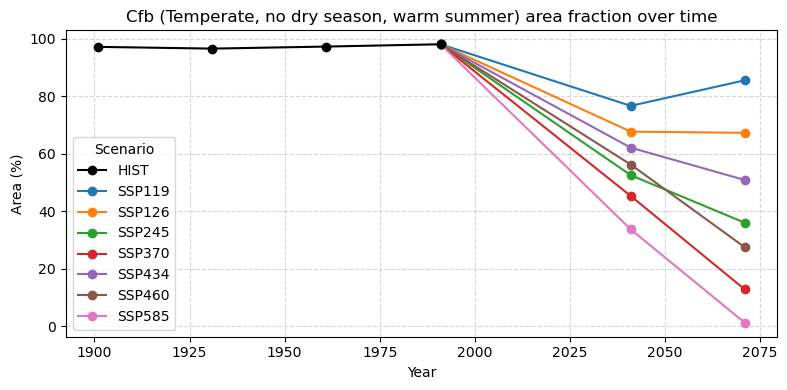

In [6]:
fig, ax = plot_climate_class_timeseries(test_func, climate_class="Cfb")
plt.show()